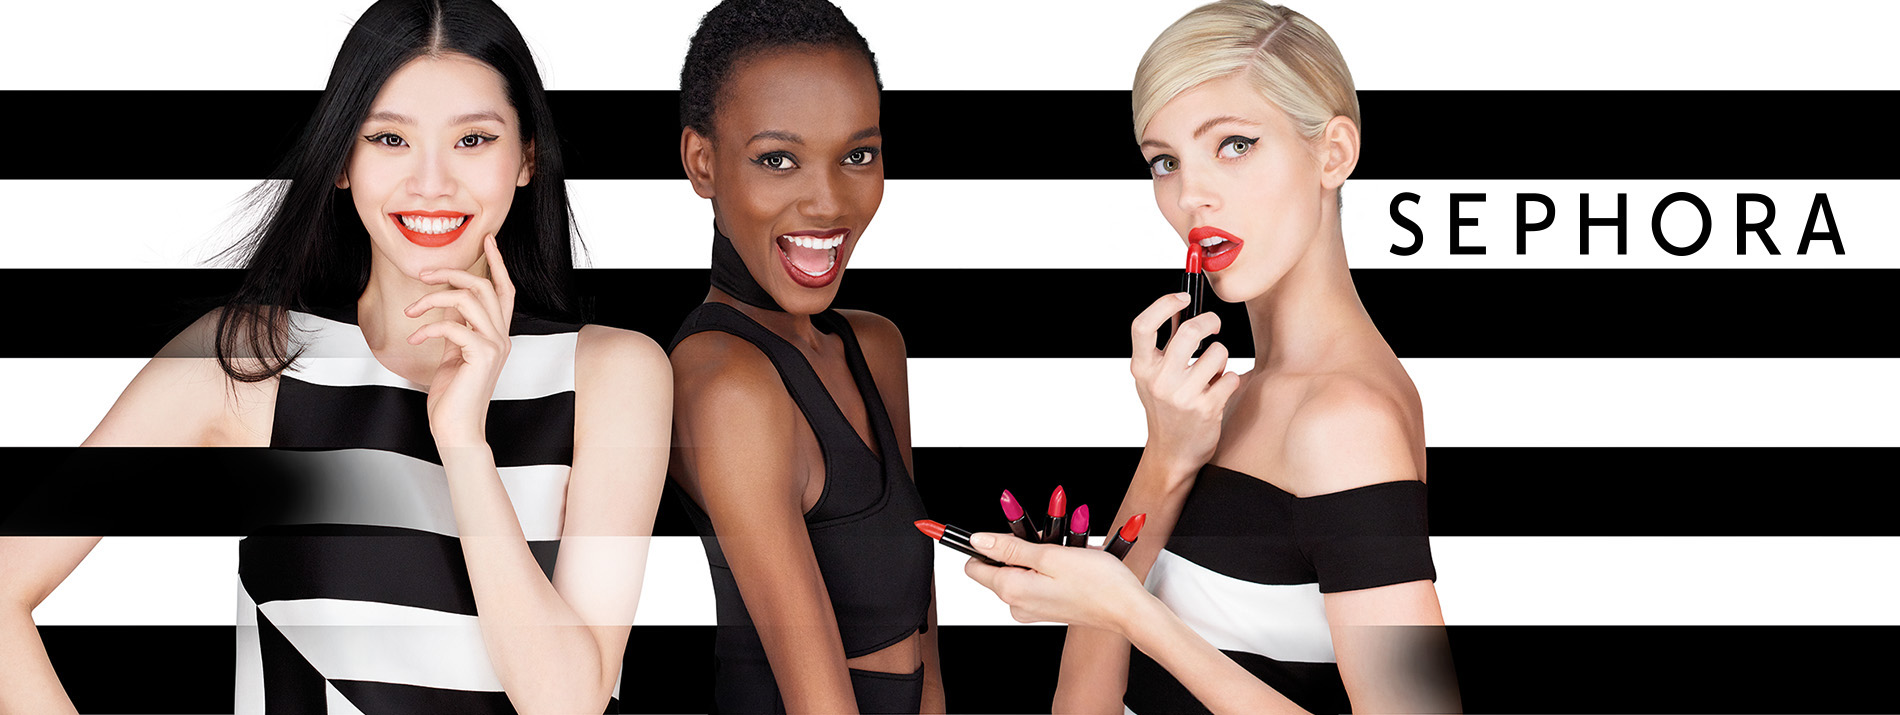

In [1]:
# ID 

prenom = "Chloé"
nom = "Makoundou"
formation = "M1 IBD"

print(f"Prénom : {prenom}\nNom : {nom}\nFormation : {formation}")

Prénom : Chloé
Nom : Makoundou
Formation : M1 IBD


# Projet de visualisation de données - Sephora Visual Analytics

## Notebook 01 - Analyse exploratoire des données (EDA)

### Introduction
Dans ce notebook, nous allons effectuer une analyse exploratoire des données (EDA) sur le dataset de Sephora. L'objectif de cette étape est de comprendre la structure des données, identifier les tendances et les relations entre les différentes variables, et préparer les données pour les étapes suivantes du projet.

**Objectifs** : Nettoyer `sephora-website-dataset.csv` pour obtenir un `sephora-website-dataset-cleaned.csv` prêt à être utilisé pour la visualisation et l'analyse.

### Données
Le dataset contient des informations sur les produits de beauté vendus par Sephora, y compris les catégories de produits, les prix, les évaluations des clients, et d'autres caractéristiques pertinentes.

lien vers le dataset : [Sephora Dataset](https://www.kaggle.com/datasets/raghadalharbi/all-products-available-on-sephora-website)

In [2]:
# Installation des bibliothèques nécessaires

Bibliothèques utilisées :
- Pandas : pour la manipulation et l'analyse des données
- NumPy : pour les opérations numériques

In [3]:
# Les imports
import pandas as pd
import numpy as np
import os
import re

In [4]:
# Chargement des données
chemin_fichier = os.path.join("..", "data", "sephora_website_dataset.csv")
df = pd.read_csv(chemin_fichier)
df.head()

,id,brand,category,name,size,rating,number_of_reviews,love,price,value_price,...,MarketingFlags,MarketingFlags_content,options,details,how_to_use,ingredients,online_only,exclusive,limited_edition,limited_time_offer
0,2218774,Acqua Di Parma,Fragrance,Blu Mediterraneo MINIATURE Set,5 x 0.16oz/5mL,4.0,4,3002,66.0,75.0,...,True,online only,no options,This enchanting set comes in a specially handc...,Suggested Usage:-Fragrance is intensified by t...,Arancia di Capri Eau de Toilette: Alcohol Dena...,1,0,0,0
1,2044816,Acqua Di Parma,Cologne,Colonia,0.7 oz/ 20 mL,4.5,76,2700,66.0,66.0,...,True,online only,- 0.7 oz/ 20 mL Spray - 1.7 oz/ 50 mL Eau d...,An elegant timeless scent filled with a fresh-...,no instructions,unknown,1,0,0,0
2,1417567,Acqua Di Parma,Perfume,Arancia di Capri,5 oz/ 148 mL,4.5,26,2600,180.0,180.0,...,True,online only,- 1oz/30mL Eau de Toilette - 2.5 oz/ 74 mL E...,Fragrance Family: Fresh Scent Type: Fresh Citr...,no instructions,Alcohol Denat.- Water- Fragrance- Limonene- Li...,1,0,0,0
3,1417617,Acqua Di Parma,Perfume,Mirto di Panarea,2.5 oz/ 74 mL,4.5,23,2900,120.0,120.0,...,True,online only,- 1 oz/ 30 mL Eau de Toilette Spray - 2.5 oz/...,Panarea near Sicily is an an island suspended ...,no instructions,unknown,1,0,0,0
4,2218766,Acqua Di Parma,Fragrance,Colonia Miniature Set,5 x 0.16oz/5mL,3.5,2,943,72.0,80.0,...,True,online only,no options,The Colonia Miniature Set comes in an iconic A...,Suggested Usage:-Fragrance is intensified by t...,Colonia: Alcohol Denat.- Water- Fragrance- Lim...,1,0,0,0


## Etape 1 - Exploration & diagnostic

In [5]:
df.shape

(9168, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      9168 non-null   int64  
 1   brand                   9168 non-null   object 
 2   category                9168 non-null   object 
 3   name                    9168 non-null   object 
 4   size                    9168 non-null   object 
 5   rating                  9168 non-null   float64
 6   number_of_reviews       9168 non-null   int64  
 7   love                    9168 non-null   int64  
 8   price                   9168 non-null   float64
 9   value_price             9168 non-null   float64
 10  URL                     9168 non-null   object 
 11  MarketingFlags          9168 non-null   bool   
 12  MarketingFlags_content  9168 non-null   object 
 13  options                 9168 non-null   object 
 14  details                 9168 non-null   

*remarque* : je remarque que mes données sont composé de **21 colonnes** et **9 000 lignes**. Je vois également que c'est homogène avec **9168 entrées** pour chaque colonnes

In [7]:
# Voyons ensuite les valeur_manquantes
valeur_manquantes = df.isnull().sum()
print("Nombre de valeurs manquantes par colonne: \n", valeur_manquantes)

Nombre de valeurs manquantes par colonne: 
 id                        0
brand                     0
category                  0
name                      0
size                      0
rating                    0
number_of_reviews         0
love                      0
price                     0
value_price               0
URL                       0
MarketingFlags            0
MarketingFlags_content    0
options                   0
details                   0
how_to_use                0
ingredients               0
online_only               0
exclusive                 0
limited_edition           0
limited_time_offer        0
dtype: int64


*remarque* : Bonne nouvelle ! on n'a pas de valeurs manquantes dans notres dataset, ce qui facilitera notre travail de nettoyage et d'analyse.

In [8]:
# Avons-nous des doublons ?

nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons dans le dataset : {nb_doublons}")

Nombre de doublons dans le dataset : 0


remarque : il n'y a pas de doublons dans notre dataset, ce qui est un bon signe pour la qualité de nos données.

In [9]:
unique_values_brand = df["brand"].unique()
print(f"Valeurs uniques de la colonne 'brand' : {unique_values_brand}")

Valeurs uniques de la colonne 'brand' : ['Acqua Di Parma' 'AERIN' 'Aether Beauty' 'Algenist' 'Alpha-H'
 'alpyn beauty' 'ALTERNA Haircare' 'amika' 'AMOREPACIFIC'
 'Anastasia Beverly Hills' 'Anthony' 'Antonym' 'Aquis' 'Armani Beauty'
 'The Art of Shaving' 'Artis' 'Artist Couture' 'Atelier Cologne'
 'BALENCIAGA' 'bareMinerals' 'Beachwaver' 'The Beauty Chef' 'BeautyBio'
 'beautyblender' 'BECCA' 'belif' 'Benefit Cosmetics' 'BERDOUES'
 'Bésame Cosmetics' 'Better Not Younger' 'Bio Ionic' 'Biossance'
 'Bite Beauty' 'bkr' 'Black Up' 'Blinc' 'Bobbi Brown' 'boscia' 'Briogeo'
 'Bumble and bumble' 'BURBERRY' 'Buxom' 'BVLGARI' 'By Rosie Jane'
 'Calvin Klein' 'Capri Blue' 'Carolina Herrera' 'Caudalie' 'Cellu-cup'
 'CHANEL' 'Charlotte Tilbury' 'Chloé' 'Christian Louboutin'
 'Christophe Robin' 'Ciaté London' 'Cinema Secrets' 'Clarins'
 'Clarisonic Skincare' 'CLEAN RESERVE' 'CLINIQUE' 'Coal and Canary'
 'Cocofloss' 'Commodity' 'Comptoir Sud Pacifique' 'Conture' 'COOLA'
 'COVER FX' 'Crushed Tonic' 'dae' 

*remarque* : En choisissant mon dataset, j'ai vu que je n'avais pas de données pour créer de la temporalité ou de la géolocalisation, ce qui m'empêche de faire des visualisations basées sur ces dimensions. C'est pourquoi, je vais rajouter des colonnes à mon dataset notamment "brand_country_of_origin" et "brand_date_founded" pour pouvoir faire des visualisations basées sur la géolocalisation et la temporalité.

Donc voici notre problème : **Comment les différentes marques de produits de beauté se répartissent-elles en fonction de leur pays d'origine et de leur date de fondation ?**

on va donc diviser le problème en deux sous-problèmes :

1. **Comment les différentes marques de produits de beauté se répartissent-elles en fonction de leur pays d'origine ?**

2. **Comment les différentes marques de produits de beauté se répartissent-elles en fonction de leur date de fondation ?**

In [10]:
df_sephora = df.copy()
df_brands = pd.read_csv("../data/helps/Brand_references_filled.csv")

df_sephora['brand'] = df_sephora['brand'].str.strip().str.lower()
df_brands['brand'] = df_brands['brand'].str.strip().str.lower()

df_merged = pd.merge(df_sephora, df_brands, on='brand', how='left')

# On s'assure que l'année est un nb 
df_merged['year_founding'] = pd.to_numeric(df_merged['year_founding'], errors='coerce')

print(df_merged['country_founding'].isnull().sum())

df_merged.to_csv("../data/helps/sephora_website_dataset_enriched.csv", index=False)

11


In [11]:
df_merged.head(5)

,id,brand,category,name,size,rating,number_of_reviews,love,price,value_price,...,options,details,how_to_use,ingredients,online_only,exclusive,limited_edition,limited_time_offer,country_founding,year_founding
0,2218774,acqua di parma,Fragrance,Blu Mediterraneo MINIATURE Set,5 x 0.16oz/5mL,4.0,4,3002,66.0,75.0,...,no options,This enchanting set comes in a specially handc...,Suggested Usage:-Fragrance is intensified by t...,Arancia di Capri Eau de Toilette: Alcohol Dena...,1,0,0,0,Italy,1916
1,2044816,acqua di parma,Cologne,Colonia,0.7 oz/ 20 mL,4.5,76,2700,66.0,66.0,...,- 0.7 oz/ 20 mL Spray - 1.7 oz/ 50 mL Eau d...,An elegant timeless scent filled with a fresh-...,no instructions,unknown,1,0,0,0,Italy,1916
2,1417567,acqua di parma,Perfume,Arancia di Capri,5 oz/ 148 mL,4.5,26,2600,180.0,180.0,...,- 1oz/30mL Eau de Toilette - 2.5 oz/ 74 mL E...,Fragrance Family: Fresh Scent Type: Fresh Citr...,no instructions,Alcohol Denat.- Water- Fragrance- Limonene- Li...,1,0,0,0,Italy,1916
3,1417617,acqua di parma,Perfume,Mirto di Panarea,2.5 oz/ 74 mL,4.5,23,2900,120.0,120.0,...,- 1 oz/ 30 mL Eau de Toilette Spray - 2.5 oz/...,Panarea near Sicily is an an island suspended ...,no instructions,unknown,1,0,0,0,Italy,1916
4,2218766,acqua di parma,Fragrance,Colonia Miniature Set,5 x 0.16oz/5mL,3.5,2,943,72.0,80.0,...,no options,The Colonia Miniature Set comes in an iconic A...,Suggested Usage:-Fragrance is intensified by t...,Colonia: Alcohol Denat.- Water- Fragrance- Lim...,1,0,0,0,Italy,1916


En réglant le problème, j'ai surement crée des problèmes de nettoyage tel que des valeurs manquantes ou des doublons, c'est pourquoi je vais devoir faire du nettoyage de données pour pouvoir faire mes visualisations.

Par exemple la marque FORM qui donne les 11 valeurs nulles pour la colonne "country_founding"

In [12]:
df_merged.loc[df_merged['brand'] == 'form', 'country_founding'] = 'United States'

print(f"Nombre de valeurs nulles : {df_merged['country_founding'].isnull().sum()}")

Nombre de valeurs nulles : 0


J'ai remarqué :
- que dans mes données la colonne "size" n'a pas de format homogène on doit choisir sois on prend oz ou ml, mais pas les deux, pour éviter les problèmes de nettoyage et de visualisation.

- on verifier si il n'y a pas de doublons, des problème d'orthographe comme USA, United States, US, etc... pour la colonne "country_founding" pour pouvoir faire des visualisations basées sur la géolocalisation.

- Ingredients a des "unknown" et des "none" qui sont des valeurs manquantes, il faudra les traiter pour pouvoir faire des visualisations basées sur les ingrédients.

- Créer une colonne région par rapport au pays de foundation par exemple amerique, europe, asie...etc.

- la colonne 'option' devrait être normalisé en nombre d'option possibles.

- Les instructions(how to use) c'est peux-être pas necessaire sinon transformer en si instruction alors true ou false 

- `url` n'est pas necessaire pour notre analyse, on peut la supprimer pour éviter les problèmes de visualisation (à rediscuter)



In [13]:
# Avons-nous des doublons à ce stade?

nb_doublons = df_merged.duplicated().sum()
print(f"Nombre de doublons dans le dataset df_merged : {nb_doublons}")

Nombre de doublons dans le dataset df_merged : 0


In [14]:
# Avons nous des valeurs manquantes à ce stade?
for col in df_merged.select_dtypes(include=['object']).columns:
    nb_unknown = (df_merged[col].str.lower() == 'unknown').sum()
    print(f"Colonne : {col} - Nombre de valeurs 'unknown' : {nb_unknown}")

Colonne : brand - Nombre de valeurs 'unknown' : 0
Colonne : category - Nombre de valeurs 'unknown' : 0
Colonne : name - Nombre de valeurs 'unknown' : 0
Colonne : size - Nombre de valeurs 'unknown' : 0
Colonne : URL - Nombre de valeurs 'unknown' : 0
Colonne : MarketingFlags_content - Nombre de valeurs 'unknown' : 0
Colonne : options - Nombre de valeurs 'unknown' : 0
Colonne : details - Nombre de valeurs 'unknown' : 0
Colonne : how_to_use - Nombre de valeurs 'unknown' : 0
Colonne : ingredients - Nombre de valeurs 'unknown' : 1630
Colonne : country_founding - Nombre de valeurs 'unknown' : 0


In [15]:
for col in df_merged.select_dtypes(include=['object']).columns:
    nb_no_ins = (df_merged[col].str.lower() == 'no instructions').sum()
    print(f"Colonne : {col} - Nombre de valeurs 'no instruction' : {nb_no_ins}")

Colonne : brand - Nombre de valeurs 'no instruction' : 0
Colonne : category - Nombre de valeurs 'no instruction' : 0
Colonne : name - Nombre de valeurs 'no instruction' : 0
Colonne : size - Nombre de valeurs 'no instruction' : 0
Colonne : URL - Nombre de valeurs 'no instruction' : 0
Colonne : MarketingFlags_content - Nombre de valeurs 'no instruction' : 0
Colonne : options - Nombre de valeurs 'no instruction' : 0
Colonne : details - Nombre de valeurs 'no instruction' : 0
Colonne : how_to_use - Nombre de valeurs 'no instruction' : 1573
Colonne : ingredients - Nombre de valeurs 'no instruction' : 0
Colonne : country_founding - Nombre de valeurs 'no instruction' : 0


In [16]:
# Affiche les valeurs uniques et leur nombre d'apparitions
print("Variantes détectées dans country_founding :")
print(df_merged['country_founding'].value_counts())
print(df_merged['country_founding'].unique())

Variantes détectées dans country_founding :
country_founding
United States     5646
France            1744
United Kingdom     460
Italy              329
South Korea        257
Canada             179
Japan              171
Australia          152
Israel              60
Germany             50
Sweden              45
Netherlands         35
Hungary             20
Greece              16
Spain                2
Singapore            2
Name: count, dtype: int64
['Italy' 'United States' 'Australia' 'South Korea' 'France' 'Spain'
 'Canada' 'United Kingdom' 'Germany' 'Sweden' 'Japan' 'Greece' 'Israel'
 'Hungary' 'Singapore' 'Netherlands']


In [17]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join( '..')))

from utils.outils import extraction_ml

# enfin, on applique la fonction
df_merged['size_ml'] = df_merged['size'].apply(extraction_ml)

# on supprime l'ancienne colonne size
df_merged = df_merged.drop(columns=['size'], axis=1)

print(df_merged[['size_ml']].head(10))

   size_ml
0      5.0
1     20.0
2    148.0
3     74.0
4      5.0
5    148.0
6    101.0
7     50.0
8     50.0
9     50.0


In [18]:
df_merged.head()

,id,brand,category,name,rating,number_of_reviews,love,price,value_price,URL,...,details,how_to_use,ingredients,online_only,exclusive,limited_edition,limited_time_offer,country_founding,year_founding,size_ml
0,2218774,acqua di parma,Fragrance,Blu Mediterraneo MINIATURE Set,4.0,4,3002,66.0,75.0,https://www.sephora.com/product/blu-mediterran...,...,This enchanting set comes in a specially handc...,Suggested Usage:-Fragrance is intensified by t...,Arancia di Capri Eau de Toilette: Alcohol Dena...,1,0,0,0,Italy,1916,5.0
1,2044816,acqua di parma,Cologne,Colonia,4.5,76,2700,66.0,66.0,https://www.sephora.com/product/colonia-P16360...,...,An elegant timeless scent filled with a fresh-...,no instructions,unknown,1,0,0,0,Italy,1916,20.0
2,1417567,acqua di parma,Perfume,Arancia di Capri,4.5,26,2600,180.0,180.0,https://www.sephora.com/product/blu-mediterran...,...,Fragrance Family: Fresh Scent Type: Fresh Citr...,no instructions,Alcohol Denat.- Water- Fragrance- Limonene- Li...,1,0,0,0,Italy,1916,148.0
3,1417617,acqua di parma,Perfume,Mirto di Panarea,4.5,23,2900,120.0,120.0,https://www.sephora.com/product/blu-mediterran...,...,Panarea near Sicily is an an island suspended ...,no instructions,unknown,1,0,0,0,Italy,1916,74.0
4,2218766,acqua di parma,Fragrance,Colonia Miniature Set,3.5,2,943,72.0,80.0,https://www.sephora.com/product/colonia-miniat...,...,The Colonia Miniature Set comes in an iconic A...,Suggested Usage:-Fragrance is intensified by t...,Colonia: Alcohol Denat.- Water- Fragrance- Lim...,1,0,0,0,Italy,1916,5.0


In [19]:
df_merged['MarketingFlags'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9168 entries, 0 to 9167
Series name: MarketingFlags
Non-Null Count  Dtype
--------------  -----
9168 non-null   bool 
dtypes: bool(1)
memory usage: 9.1 KB


In [20]:
df_merged['MarketingFlags_content'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9168 entries, 0 to 9167
Series name: MarketingFlags_content
Non-Null Count  Dtype 
--------------  ----- 
9168 non-null   object
dtypes: object(1)
memory usage: 71.8+ KB


In [21]:
print(df_merged['MarketingFlags_content'].unique())

['online only' 'exclusive · online only' '0'
 'limited edition · exclusive · online only'
 'limited edition · online only' 'exclusive' 'limited edition · exclusive'
 'limited edition' 'limited time offer'
 'limited time offer · limited edition · exclusive']


In [22]:
print(df_merged['online_only'].info())
print(df_merged['exclusive'].info())
print(df_merged['limited_edition'].info())
print(df_merged['limited_time_offer'].info())

<class 'pandas.core.series.Series'>
RangeIndex: 9168 entries, 0 to 9167
Series name: online_only
Non-Null Count  Dtype
--------------  -----
9168 non-null   int64
dtypes: int64(1)
memory usage: 71.8 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 9168 entries, 0 to 9167
Series name: exclusive
Non-Null Count  Dtype
--------------  -----
9168 non-null   int64
dtypes: int64(1)
memory usage: 71.8 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 9168 entries, 0 to 9167
Series name: limited_edition
Non-Null Count  Dtype
--------------  -----
9168 non-null   int64
dtypes: int64(1)
memory usage: 71.8 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 9168 entries, 0 to 9167
Series name: limited_time_offer
Non-Null Count  Dtype
--------------  -----
9168 non-null   int64
dtypes: int64(1)
memory usage: 71.8 KB
None


['online only' 'exclusive · online only' 'aucun'
 'limited edition · exclusive · online only'
 'limited edition · online only' 'exclusive' 'limited edition · exclusive'
 'limited edition' 'limited time offer'
 'limited time offer · limited edition · exclusive']

In [23]:
# Il y a du bruit dans la colonne "MarketingFlags_content" 

df_merged['MarketingFlags_content'] = df_merged['MarketingFlags_content'].replace('0','aucun')

flag_cols = ['online_only', 'exclusive', 'limited_edition', 'limited_time_offer']
for col in flag_cols:
    df_merged[col] = df_merged[col].astype(bool)

# On vérifie si un produit a 'exclusive' dans son texte mais 0 dans sa colonne
check = df_merged[df_merged['MarketingFlags_content'].str.contains('exclusive', na=False) & (df_merged['exclusive'] == False)]
print(f"Nombre d'incohérences détectées : {len(check)}")

Nombre d'incohérences détectées : 0


In [24]:
df_merged['MarketingFlags_content'].head(20)

0                                   online only
1                                   online only
2                                   online only
3                                   online only
4                                   online only
5                                   online only
6                                   online only
7                                   online only
8                                   online only
9                       exclusive · online only
10                                  online only
11                                        aucun
12                                  online only
13                                  online only
14                                  online only
15    limited edition · exclusive · online only
16                                  online only
17                                  online only
18                                  online only
19                                  online only
Name: MarketingFlags_content, dtype: obj

In [25]:
df_merged.drop(['MarketingFlags_content'], axis=1, inplace=True)

In [26]:
df_merged.head(5)

,id,brand,category,name,rating,number_of_reviews,love,price,value_price,URL,...,details,how_to_use,ingredients,online_only,exclusive,limited_edition,limited_time_offer,country_founding,year_founding,size_ml
0,2218774,acqua di parma,Fragrance,Blu Mediterraneo MINIATURE Set,4.0,4,3002,66.0,75.0,https://www.sephora.com/product/blu-mediterran...,...,This enchanting set comes in a specially handc...,Suggested Usage:-Fragrance is intensified by t...,Arancia di Capri Eau de Toilette: Alcohol Dena...,True,False,False,False,Italy,1916,5.0
1,2044816,acqua di parma,Cologne,Colonia,4.5,76,2700,66.0,66.0,https://www.sephora.com/product/colonia-P16360...,...,An elegant timeless scent filled with a fresh-...,no instructions,unknown,True,False,False,False,Italy,1916,20.0
2,1417567,acqua di parma,Perfume,Arancia di Capri,4.5,26,2600,180.0,180.0,https://www.sephora.com/product/blu-mediterran...,...,Fragrance Family: Fresh Scent Type: Fresh Citr...,no instructions,Alcohol Denat.- Water- Fragrance- Limonene- Li...,True,False,False,False,Italy,1916,148.0
3,1417617,acqua di parma,Perfume,Mirto di Panarea,4.5,23,2900,120.0,120.0,https://www.sephora.com/product/blu-mediterran...,...,Panarea near Sicily is an an island suspended ...,no instructions,unknown,True,False,False,False,Italy,1916,74.0
4,2218766,acqua di parma,Fragrance,Colonia Miniature Set,3.5,2,943,72.0,80.0,https://www.sephora.com/product/colonia-miniat...,...,The Colonia Miniature Set comes in an iconic A...,Suggested Usage:-Fragrance is intensified by t...,Colonia: Alcohol Denat.- Water- Fragrance- Lim...,True,False,False,False,Italy,1916,5.0


In [27]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  9168 non-null   int64  
 1   brand               9168 non-null   object 
 2   category            9168 non-null   object 
 3   name                9168 non-null   object 
 4   rating              9168 non-null   float64
 5   number_of_reviews   9168 non-null   int64  
 6   love                9168 non-null   int64  
 7   price               9168 non-null   float64
 8   value_price         9168 non-null   float64
 9   URL                 9168 non-null   object 
 10  MarketingFlags      9168 non-null   bool   
 11  options             9168 non-null   object 
 12  details             9168 non-null   object 
 13  how_to_use          9168 non-null   object 
 14  ingredients         9168 non-null   object 
 15  online_only         9168 non-null   bool   
 16  exclus

In [28]:
df_merged['ingredients'].unique()

array(['Arancia di Capri Eau de Toilette: Alcohol Denat.- Water- Fragrance- Limonene- Linalool- Ethylhexyl Methoxycinnamate- Citral- Butyl Methoxydibenzoylmethane- Ethylhexyl Salicylate- BHT- Geraniol- Benzyl Alcohol- Citronellol- Tocopherol.Bergamotto di Calabria Eau de Toilette:Alcohol Denat.- Fragrance- Water- Limonene- Ethylhexyl Methoxycinnamate- Linalool- Citral- Butyl Methoxydibenzoylmethane- Ethylhexyl Salicylate- Alpha-Isomethyl Ionone- Bht- Citronellol- Geraniol. Fico di Amalfi Eau de Toilette: Alcohol Denat.- Fragrance- Water- Limonene- Ethylhexyl Methoxycinnamate- Linalool- Alpha-Isomethyl Ionone- Hexyl Cinnamal- Butyl Methoxydibenzoylmethane- Ethylhexylsalicylate- Bht- Citronellol- Hydroxycitronellal- Coumarin- Citral- Geraniol- Amyl Cinnamal- Benzyl Salicylate- Butylphenyl Methylpropional- Benzyl Alcohol- Eugenol- Benzyl Benzoate- Disodium EDTA.Mirto di Panarea Eau de Toilette:Alcohol Denat.- Fragrance- Water- Limonene- Linalool- Butylphenyl Methylpropional- Hexyl Cinnama

In [29]:
df_merged['how_to_use'].unique()

array(['Suggested Usage:-Fragrance is intensified by the warmth of your own body. Apply in the creases of your knees and elbows for a longer-lasting- stronger scent.\xa0-After applying- avoid rubbing or dabbing skin. This breaks down the fragrance- causing it to wear off more quickly.\xa0-If you prefer placing fragrance on your wrists- be sure to reapply after frequent hand-washing- as this tends to rinse off the scent.\xa0-Replace fragrance after 12 months. Expired perfumes more than a year old lose the integrity of the original scent. Eau de Toilette or Eau de Parfum?: The difference lies in the volume of perfume oil. While EDT contains five to nine percent- EDP contains more- usually eight to 14 percent. EDPs- therefore- last longer and smell more intense.',
       'no instructions',
       'Suggested Usage:-Spray over your hair to leave it delicately scented with the notes of Peonia Nobile.',
       ...,
       'Suggested Usage:-Apply to wet skin.-Massage in to the skin. -Rinse.',


In [30]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))
from utils.outils import clean_how_to_use

df_merged['usage_instructions'] = df_merged['how_to_use'].apply(clean_how_to_use)
df_merged = df_merged.drop(columns=['how_to_use'])

In [31]:
print(df_merged['usage_instructions'].value_counts())

usage_instructions
True     7595
False    1573
Name: count, dtype: int64


In [32]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  9168 non-null   int64  
 1   brand               9168 non-null   object 
 2   category            9168 non-null   object 
 3   name                9168 non-null   object 
 4   rating              9168 non-null   float64
 5   number_of_reviews   9168 non-null   int64  
 6   love                9168 non-null   int64  
 7   price               9168 non-null   float64
 8   value_price         9168 non-null   float64
 9   URL                 9168 non-null   object 
 10  MarketingFlags      9168 non-null   bool   
 11  options             9168 non-null   object 
 12  details             9168 non-null   object 
 13  ingredients         9168 non-null   object 
 14  online_only         9168 non-null   bool   
 15  exclusive           9168 non-null   bool   
 16  limite

In [33]:
print(df_merged['options'].unique())

['no options'
 ' - 0.7 oz/ 20 mL  Spray  - 1.7 oz/ 50 mL Eau de Cologne Spray - 3.4 oz/ 101 mL Eau de Cologne Spray'
 ' - 1oz/30mL Eau de Toilette  - 2.5 oz/ 74 mL Eau de Toilette Spray - 5 oz/ 148 mL Eau de Toilette Spray '
 ' - 1 oz/ 30 mL Eau de Toilette Spray - 2.5 oz/ 74 mL Eau de Toilette Spray  - 5 oz/ 148 mL Eau de Toilette Spray'
 ' - 0.7 oz, 20 mL Eau de Parfum Spray - 1.7 oz/ 50 mL Eau de Parfum Spray - 3.4 oz/ 101 mL Eau de Parfum Spray '
 ' - 1.7 oz/ 50 mL Eau de Cologne Spray  - 3.4 oz/ 101 mL Eau de Cologne Spray'
 ' - 1.7oz/50mL  Hair Mist  - 0.70oz/20mL Eau de Parfum Spray'
 ' - 1.7oz/50mL  Hair Mist '
 ' - 1 oz / 30 mL Eau de Toilette Spray - 2.5 oz / 75 mL Eau de Toilette Spray '
 ' - 1 oz/ 30 mL Eau de Toilette Spray - 2.5 oz/ 74 mL Eau de Toilette Spray '
 ' - 0.70oz/20mL Eau de Parfum Spray - 1.7 oz/ 50 mL Eau de Parfum Spray  - 3.4 oz/ 100 mL Eau de Parfum Spray'
 ' - 1oz/30mL Eau de Toilette  - 2.5 oz/ 74 mL Eau de Toilette Spray  - 5 oz/ 148 mL Eau de Toilette 

In [34]:
# sys.path.append(os.path.abspath(os.path.join('..')))
from utils.outils import count_options

df_merged['nb_formats'] = df_merged['options'].apply(count_options)
df_merged = df_merged.drop(columns=['options'])


In [35]:
print(df_merged['nb_formats'].value_counts())
print(df_merged['nb_formats'].unique())

nb_formats
1    8602
2     310
3     159
4      77
5      17
6       3
Name: count, dtype: int64
[1 3 2 4 5 6]


In [36]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  9168 non-null   int64  
 1   brand               9168 non-null   object 
 2   category            9168 non-null   object 
 3   name                9168 non-null   object 
 4   rating              9168 non-null   float64
 5   number_of_reviews   9168 non-null   int64  
 6   love                9168 non-null   int64  
 7   price               9168 non-null   float64
 8   value_price         9168 non-null   float64
 9   URL                 9168 non-null   object 
 10  MarketingFlags      9168 non-null   bool   
 11  details             9168 non-null   object 
 12  ingredients         9168 non-null   object 
 13  online_only         9168 non-null   bool   
 14  exclusive           9168 non-null   bool   
 15  limited_edition     9168 non-null   bool   
 16  limite

On a finit la normalisation des colonne qui en avaient besoin.

On se pose la question de si il faut enlever
```python
name
url
details
ingredients
```
et ensuite il faut tout reverifier si il y a des valeurs manquantes, doublons, ...etc.

In [37]:
print(df_merged['ingredients'].unique())

['Arancia di Capri Eau de Toilette: Alcohol Denat.- Water- Fragrance- Limonene- Linalool- Ethylhexyl Methoxycinnamate- Citral- Butyl Methoxydibenzoylmethane- Ethylhexyl Salicylate- BHT- Geraniol- Benzyl Alcohol- Citronellol- Tocopherol.Bergamotto di Calabria Eau de Toilette:Alcohol Denat.- Fragrance- Water- Limonene- Ethylhexyl Methoxycinnamate- Linalool- Citral- Butyl Methoxydibenzoylmethane- Ethylhexyl Salicylate- Alpha-Isomethyl Ionone- Bht- Citronellol- Geraniol. Fico di Amalfi Eau de Toilette: Alcohol Denat.- Fragrance- Water- Limonene- Ethylhexyl Methoxycinnamate- Linalool- Alpha-Isomethyl Ionone- Hexyl Cinnamal- Butyl Methoxydibenzoylmethane- Ethylhexylsalicylate- Bht- Citronellol- Hydroxycitronellal- Coumarin- Citral- Geraniol- Amyl Cinnamal- Benzyl Salicylate- Butylphenyl Methylpropional- Benzyl Alcohol- Eugenol- Benzyl Benzoate- Disodium EDTA.Mirto di Panarea Eau de Toilette:Alcohol Denat.- Fragrance- Water- Limonene- Linalool- Butylphenyl Methylpropional- Hexyl Cinnamal- Cit

trop d'ingredients différents, on peut pas faire de visualisation basée sur les ingrédients, on va donc supprimer cette colonne pour éviter les problèmes de visualisation.

In [38]:
df_merged = df_merged.drop(columns=['ingredients'])

In [39]:
# same for details

df_merged = df_merged.drop(columns=['details'])

In [40]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  9168 non-null   int64  
 1   brand               9168 non-null   object 
 2   category            9168 non-null   object 
 3   name                9168 non-null   object 
 4   rating              9168 non-null   float64
 5   number_of_reviews   9168 non-null   int64  
 6   love                9168 non-null   int64  
 7   price               9168 non-null   float64
 8   value_price         9168 non-null   float64
 9   URL                 9168 non-null   object 
 10  MarketingFlags      9168 non-null   bool   
 11  online_only         9168 non-null   bool   
 12  exclusive           9168 non-null   bool   
 13  limited_edition     9168 non-null   bool   
 14  limited_time_offer  9168 non-null   bool   
 15  country_founding    9168 non-null   object 
 16  year_f

In [41]:
df_merged['country_founding'].unique()

array(['Italy', 'United States', 'Australia', 'South Korea', 'France',
       'Spain', 'Canada', 'United Kingdom', 'Germany', 'Sweden', 'Japan',
       'Greece', 'Israel', 'Hungary', 'Singapore', 'Netherlands'],
      dtype=object)

In [42]:
# Rajoutons une colonne région

region_map = {
    'Italy': 'Europe',
    'France': 'Europe',
    'Spain': 'Europe',
    'United Kingdom': 'Europe',
    'Germany': 'Europe',
    'Sweden': 'Europe',
    'Greece': 'Europe',
    'Hungary': 'Europe',
    'Netherlands': 'Europe',
    'United States': 'North America',
    'Canada': 'North America',
    'South Korea': 'Asia',
    'Japan': 'Asia',
    'Singapore': 'Asia',
    'Israel': 'Middle East',
    'Australia': 'Oceania'
}

df_merged['region'] = df_merged['country_founding'].map(region_map)

In [43]:
from utils.outils import segment_prix
   
df_merged['price_segment'] = df_merged["value_price"].apply(segment_prix)

en fonction de value price parce que value price est la valeur réelle du produit car dans le site parfois il est affiché avec une réduction

In [44]:
from utils.outils import calculate_brand_age, brand_status

df_merged['brand_age'] = df_merged['year_founding'].apply(calculate_brand_age)

# ajout du statut de la marque en fonction du brand age
df_merged['brand_status'] = df_merged['brand_age'].apply(brand_status)


In [45]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  9168 non-null   int64  
 1   brand               9168 non-null   object 
 2   category            9168 non-null   object 
 3   name                9168 non-null   object 
 4   rating              9168 non-null   float64
 5   number_of_reviews   9168 non-null   int64  
 6   love                9168 non-null   int64  
 7   price               9168 non-null   float64
 8   value_price         9168 non-null   float64
 9   URL                 9168 non-null   object 
 10  MarketingFlags      9168 non-null   bool   
 11  online_only         9168 non-null   bool   
 12  exclusive           9168 non-null   bool   
 13  limited_edition     9168 non-null   bool   
 14  limited_time_offer  9168 non-null   bool   
 15  country_founding    9168 non-null   object 
 16  year_f

In [46]:
df_merged.head(5)

,id,brand,category,name,rating,number_of_reviews,love,price,value_price,URL,...,limited_time_offer,country_founding,year_founding,size_ml,usage_instructions,nb_formats,region,price_segment,brand_age,brand_status
0,2218774,acqua di parma,Fragrance,Blu Mediterraneo MINIATURE Set,4.0,4,3002,66.0,75.0,https://www.sephora.com/product/blu-mediterran...,...,False,Italy,1916,5.0,True,1,Europe,premium,110,heritage
1,2044816,acqua di parma,Cologne,Colonia,4.5,76,2700,66.0,66.0,https://www.sephora.com/product/colonia-P16360...,...,False,Italy,1916,20.0,False,3,Europe,premium,110,heritage
2,1417567,acqua di parma,Perfume,Arancia di Capri,4.5,26,2600,180.0,180.0,https://www.sephora.com/product/blu-mediterran...,...,False,Italy,1916,148.0,False,3,Europe,luxury,110,heritage
3,1417617,acqua di parma,Perfume,Mirto di Panarea,4.5,23,2900,120.0,120.0,https://www.sephora.com/product/blu-mediterran...,...,False,Italy,1916,74.0,False,3,Europe,luxury,110,heritage
4,2218766,acqua di parma,Fragrance,Colonia Miniature Set,3.5,2,943,72.0,80.0,https://www.sephora.com/product/colonia-miniat...,...,False,Italy,1916,5.0,True,1,Europe,premium,110,heritage


On va checker les valeurs aberrantes pour les prix et les ratings pour éviter les problèmes de visualisation.

In [47]:
df_merged[df_merged['price'] < 0]

,id,brand,category,name,rating,number_of_reviews,love,price,value_price,URL,...,limited_time_offer,country_founding,year_founding,size_ml,usage_instructions,nb_formats,region,price_segment,brand_age,brand_status


In [48]:
df_merged[(df_merged['rating'] < 0) | (df_merged['rating'] > 5)]

,id,brand,category,name,rating,number_of_reviews,love,price,value_price,URL,...,limited_time_offer,country_founding,year_founding,size_ml,usage_instructions,nb_formats,region,price_segment,brand_age,brand_status


In [49]:
df_merged.describe()

,id,rating,number_of_reviews,love,price,value_price,year_founding,size_ml,nb_formats,brand_age
count,9.168000e+03,9168.000000,9168.000000,9.168000e+03,9168.000000,9168.00000,9168.000000,4513.000000,9168.000000,9168.000000
mean,1.962952e+06,3.990020,282.139180,1.627859e+04,50.063237,51.82359,1988.991383,79.483962,1.102749,37.008617
std,3.859714e+05,1.007707,890.642028,4.260651e+04,47.164989,49.45902,35.589524,86.850083,0.453969,35.589524
min,5.000000e+01,0.000000,0.000000,0.000000e+00,2.000000,2.00000,1789.000000,0.000000,1.000000,6.000000
25%,1.819453e+06,4.000000,10.000000,1.600000e+03,24.000000,25.00000,1986.000000,15.000000,1.000000,16.000000
50%,2.072354e+06,4.000000,46.000000,4.800000e+03,35.000000,35.00000,1999.000000,50.000000,1.000000,27.000000
75%,2.230591e+06,4.500000,210.000000,1.380000e+04,59.000000,60.00000,2010.000000,100.550000,1.000000,40.000000
max,2.359685e+06,5.000000,19000.000000,1.300000e+06,549.000000,549.00000,2020.000000,1656.120000,6.000000,237.000000


In [50]:
# On cherche la marque qui a exactement 237 ans
oldest_brand = df_merged[df_merged['brand_age'] == 237][['name','brand', 'year_founding']].drop_duplicates()

print("La marque la plus ancienne est :")
print(oldest_brand)

La marque la plus ancienne est :
                                                   name  brand  year_founding
2774    Brumisateur® Natural Mineral Water Facial Spray  evian           1789
2775  Brumisateur® Natural Mineral Water Facial Spra...  evian           1789
2776  Brumisateur® Natural Mineral Water Facial Spra...  evian           1789


In [51]:
nb_zeros = (df_merged['size_ml'] == 0).sum()
print(f"Nombre de 0 : {nb_zeros}")

Nombre de 0 : 11


In [52]:
nb_nulls = df_merged['size_ml'].isna().sum()
print(f"Nombre de NaN : {nb_nulls}")

Nombre de NaN : 4655


In [53]:
df_merged['size_ml'] = df_merged['size_ml'].replace(0, np.nan)

# On vérifie que le compte est maintenant cohérent
print(f"\nAprès correction, valeurs nulles : {df_merged['size_ml'].isna().sum()}")


Après correction, valeurs nulles : 4666


In [54]:
df_merged[df_merged['size_ml'].isna()].head()

,id,brand,category,name,rating,number_of_reviews,love,price,value_price,URL,...,limited_time_offer,country_founding,year_founding,size_ml,usage_instructions,nb_formats,region,price_segment,brand_age,brand_status
15,2295228,acqua di parma,Fragrance,Blu Mediterraneo Discovery Collection Rollerba...,4.0,1,594,80.0,95.0,https://www.sephora.com/product/blu-mediterran...,...,False,Italy,1916,NaN,True,1,Europe,premium,110,heritage
18,967224,acqua di parma,Body Sprays & Deodorant,Colonia Alcohol-Free Deodorant,3.5,7,400,50.0,50.0,https://www.sephora.com/product/colonia-deodor...,...,False,Italy,1916,NaN,False,1,Europe,middle,110,heritage
20,2295210,acqua di parma,Perfume Gift Sets,Blu Mediterraneo Fico di Amalfi Gift Set,5.0,1,211,113.0,143.0,https://www.sephora.com/product/blu-mediterran...,...,False,Italy,1916,NaN,True,1,Europe,luxury,110,heritage
27,2295236,acqua di parma,Perfume,Osmanthus Eau de Parfum,5.0,2,464,275.0,275.0,https://www.sephora.com/product/osmanthus-eau-...,...,False,Italy,1916,NaN,True,1,Europe,luxury,110,heritage
28,2295194,acqua di parma,Perfume Gift Sets,Peonia Nobile Gift Set,5.0,1,153,200.0,279.0,https://www.sephora.com/product/peonia-nobile-...,...,False,Italy,1916,NaN,True,1,Europe,luxury,110,heritage


In [55]:
df_merged.head(10)

,id,brand,category,name,rating,number_of_reviews,love,price,value_price,URL,...,limited_time_offer,country_founding,year_founding,size_ml,usage_instructions,nb_formats,region,price_segment,brand_age,brand_status
0,2218774,acqua di parma,Fragrance,Blu Mediterraneo MINIATURE Set,4.0,4,3002,66.0,75.0,https://www.sephora.com/product/blu-mediterran...,...,False,Italy,1916,5.0,True,1,Europe,premium,110,heritage
1,2044816,acqua di parma,Cologne,Colonia,4.5,76,2700,66.0,66.0,https://www.sephora.com/product/colonia-P16360...,...,False,Italy,1916,20.0,False,3,Europe,premium,110,heritage
2,1417567,acqua di parma,Perfume,Arancia di Capri,4.5,26,2600,180.0,180.0,https://www.sephora.com/product/blu-mediterran...,...,False,Italy,1916,148.0,False,3,Europe,luxury,110,heritage
3,1417617,acqua di parma,Perfume,Mirto di Panarea,4.5,23,2900,120.0,120.0,https://www.sephora.com/product/blu-mediterran...,...,False,Italy,1916,74.0,False,3,Europe,luxury,110,heritage
4,2218766,acqua di parma,Fragrance,Colonia Miniature Set,3.5,2,943,72.0,80.0,https://www.sephora.com/product/colonia-miniat...,...,False,Italy,1916,5.0,True,1,Europe,premium,110,heritage
5,1417609,acqua di parma,Perfume,Fico di Amalfi,4.5,79,2600,180.0,180.0,https://www.sephora.com/product/blu-mediterran...,...,False,Italy,1916,148.0,False,3,Europe,luxury,110,heritage
6,1638832,acqua di parma,Perfume,Rosa Nobile,4.5,79,5000,210.0,210.0,https://www.sephora.com/product/rosa-nobile-P3...,...,False,Italy,1916,101.0,False,3,Europe,luxury,110,heritage
7,1284462,acqua di parma,Cologne,Colonia Essenza,5.0,13,719,120.0,120.0,https://www.sephora.com/product/colonia-essenz...,...,False,Italy,1916,50.0,False,2,Europe,luxury,110,heritage
8,2221588,acqua di parma,Body Mist & Hair Mist,Peonia Nobile Hair Mist,4.0,5,800,58.0,58.0,https://www.sephora.com/product/peonia-nobile-...,...,False,Italy,1916,50.0,True,2,Europe,premium,110,heritage
9,2221596,acqua di parma,Perfume,Rosa Nobile Hair Mist,3.0,5,2100,58.0,58.0,https://www.sephora.com/product/rosa-nobile-ha...,...,False,Italy,1916,50.0,True,1,Europe,premium,110,heritage


Je dois regrouper les categories de produits pour éviter d'avoir trop de catégories différentes qui peuvent rendre les visualisations difficiles à interpréter.

In [56]:
from utils.outils import mapping_categories

df_merged['univers_produit'] = df_merged['category'].apply(mapping_categories)

Pour moi le Dataset est propre et prêt à être utilisé pour la visualisation et l'analyse, on peut donc le sauvegarder sous le nom `sephora-website-dataset-cleaned.csv` pour pouvoir l'utiliser dans les étapes suivantes du projet.

In [57]:
# On génère le nouveau CSV clean
df_merged.to_csv('sephora_clean_final_2026.csv', index=False, encoding='utf-8-sig')

In [58]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  9168 non-null   int64  
 1   brand               9168 non-null   object 
 2   category            9168 non-null   object 
 3   name                9168 non-null   object 
 4   rating              9168 non-null   float64
 5   number_of_reviews   9168 non-null   int64  
 6   love                9168 non-null   int64  
 7   price               9168 non-null   float64
 8   value_price         9168 non-null   float64
 9   URL                 9168 non-null   object 
 10  MarketingFlags      9168 non-null   bool   
 11  online_only         9168 non-null   bool   
 12  exclusive           9168 non-null   bool   
 13  limited_edition     9168 non-null   bool   
 14  limited_time_offer  9168 non-null   bool   
 15  country_founding    9168 non-null   object 
 16  year_f

On passe a l'étape suivante qui est la visualisation des données pour répondre à nos questions de recherche. -> TABLEAU Public 